# Bertrand's Paradox

## Problem

A circle of radius \(R\) is given.

A **random chord** is drawn.

What is the probability that the chord is **longer than the side of the inscribed equilateral triangle**?

The side length of an inscribed equilateral triangle is

$$
L=\sqrt{3}R.
$$

The surprising result is that the answer depends on **how the random chord is generated**.

---

# Method 1: Random Endpoints

Two endpoints are chosen independently and uniformly on the circumference.

Let one endpoint be fixed.

The other endpoint is uniformly distributed on the circle.

The chord subtends an angle

$$
\theta.
$$

The chord length is

$$
\ell=2R\sin\left(\frac{\theta}{2}\right).
$$

The chord is longer than the triangle side if

$$
2R\sin\left(\frac{\theta}{2}\right)>\sqrt{3}R.
$$

Dividing by \(2R\),

$$
\sin\left(\frac{\theta}{2}\right)>
\frac{\sqrt3}{2}.
$$

Therefore,

$$
\frac{\theta}{2}>60^\circ,
$$

or

$$
\theta>120^\circ.
$$

Since

$$
0\le\theta\le180^\circ,
$$

the favorable interval is

$$
120^\circ<\theta<180^\circ.
$$

Hence,

$$
P
=
\frac{180^\circ-120^\circ}{180^\circ}
=
\frac{60}{180}
=
\boxed{\frac13.}
$$

---

# Method 2: Random Midpoint

Choose the midpoint uniformly inside the circle.

A chord is uniquely determined by its midpoint.

Suppose the midpoint is at distance \(r\) from the center.

The chord length is

$$
\ell
=
2\sqrt{R^2-r^2}.
$$

We require

$$
2\sqrt{R^2-r^2}>
\sqrt3R.
$$

Squaring,

$$
4(R^2-r^2)>3R^2.
$$

Thus,

$$
R^2>4r^2.
$$

Therefore,

$$
r<\frac{R}{2}.
$$

The midpoint must lie inside the smaller circle of radius

$$
\frac{R}{2}.
$$

Since the midpoint is uniformly distributed over area,

$$
P
=
\frac{\pi(R/2)^2}
{\pi R^2}
=
\frac14.
$$

Hence,

$$
\boxed{P=\frac14.}
$$

---

# Method 3: Random Radius

Choose a radius uniformly.

Then choose a point uniformly along that radius.

Construct the chord perpendicular to the radius through that point.

Let

$$
r
$$

be the distance from the center.

Again,

$$
\ell
=
2\sqrt{R^2-r^2}.
$$

For the chord to be longer than the triangle side,

$$
2\sqrt{R^2-r^2}>
\sqrt3R.
$$

Exactly as before,

$$
r<\frac{R}{2}.
$$

However,

here \(r\) is chosen **uniformly along the radius**, not uniformly over the area.

Therefore,

the favorable interval is

$$
0<r<\frac{R}{2}.
$$

Out of the total interval

$$
0<r<R,
$$

the probability is

$$
P
=
\frac{R/2}{R}
=
\boxed{\frac12.}
$$

---

# Summary

| Method | Sample Space | Probability |
|---------|--------------|-------------|
| Random Endpoints | Uniform angle on circumference | $$\boxed{\frac13}$$ |
| Random Midpoint | Uniform area inside circle | $$\boxed{\frac14}$$ |
| Random Radius | Uniform distance along radius | $$\boxed{\frac12}$$ |

---

# Why This Is a Paradox

Each method uses a different definition of **"random chord."**

The sample space changes:

- Uniform points on the circumference
- Uniform points in the area
- Uniform points along a radius

Since probability depends on the sample space, each method produces a different (yet mathematically correct) answer.

**Lesson:** Before solving a probability problem, the random experiment must be defined precisely.

# Method 1: Random Endpoints (Probability = 1/3)

Experimental = 0.3389
Theory = 1/3


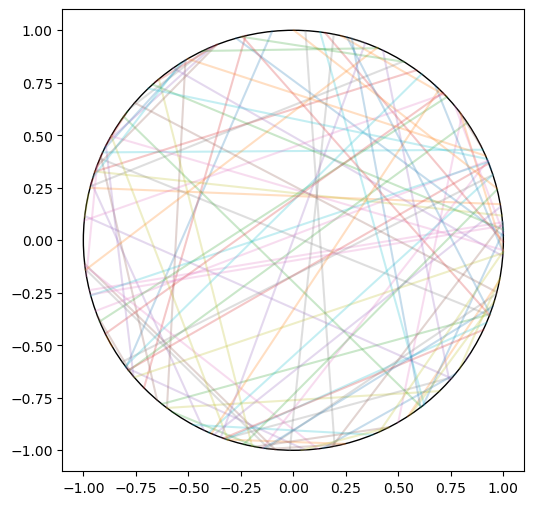

In [1]:
import numpy as np
import matplotlib.pyplot as plt

R = 1
N = 10000

count = 0

fig, ax = plt.subplots(figsize=(6,6))

circle = plt.Circle((0,0),R,fill=False)
ax.add_patch(circle)

for i in range(N):

    t1 = np.random.uniform(0,2*np.pi)
    t2 = np.random.uniform(0,2*np.pi)

    p1 = np.array([np.cos(t1),np.sin(t1)])
    p2 = np.array([np.cos(t2),np.sin(t2)])

    length = np.linalg.norm(p1-p2)

    if length > np.sqrt(3):
        count += 1

    if i < 100:
        ax.plot([p1[0],p2[0]],
                [p1[1],p2[1]],
                alpha=0.25)

ax.set_aspect("equal")
ax.set_xlim(-1.1,1.1)
ax.set_ylim(-1.1,1.1)

print("Experimental =",count/N)
print("Theory = 1/3")

plt.show()

# Method 2: Random Midpoint (Probability = 1/4)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

R = 1
N = 10000

count = 0

for _ in range(N):

    # Uniform midpoint in circle
    r = np.sqrt(np.random.rand())
    theta = np.random.rand()*2*np.pi

    x = r*np.cos(theta)
    y = r*np.sin(theta)

    d = np.sqrt(x*x+y*y)

    if d < 0.5:
        count += 1

print("Experimental =",count/N)
print("Theory = 1/4")

Experimental = 0.2517
Theory = 1/4


# Method 3: Random Radius (Probability = 1/2)

In [3]:
import numpy as np

R = 1
N = 100000

count = 0

for _ in range(N):

    theta = np.random.rand()*2*np.pi

    r = np.random.rand()

    if r < 0.5:
        count += 1

print("Experimental =",count/N)
print("Theory = 1/2")

Experimental = 0.49902
Theory = 1/2


#  Simulates the infinite coin toss bet between Player A (odd tosses) and Player B (even tosses) over a large number of trials.
  

In [1]:
import random

In [5]:
def simulate_first_head_game(p=0.5,num_tosses=10000):
    A_wins = 0
    B_wins = 0
    
    print(f"Starting the Infinite Coin toss game of {num_tosses}")
    print(f"The coin landing  on head probability is p = {p}")
    for _ in range(num_tosses):
        toss_count = 1
        # Infinite loop mimicking the infinite coin toss sequence
        while True:
            # random.random() returns a float between 0.0 and 1.0
            if random.random() < p:
                # Head found! Determine winner based on odd/even toss count
                if toss_count %2 != 0 :
                    A_wins += 1
                else :
                    B_wins += 1
                break # Game ends when the first Head appears
            toss_count +=1
        # Calculate experimental probabilities
        prob_A_expt = A_wins / num_tosses
        prob_B_expt = B_wins / num_tosses
        
        prob_A_theory = 1 / (2 - p)
        prob_B_theory = (1-p) / (2 - p)
        
        # Results 
        print("======= EXPT RESULTS ==========")
        print(f"Player A (Odd) Wins:  {A_wins} times ({prob_A_expt:.4%})")
        print(f"Player B (Even) Wins: {B_wins} times ({prob_B_expt:.4%})")
        
        print("\n====== THEORETICAL RESULTS ======")
        print(f"Player A Expected:    {prob_A_theory:.4%}")
        print(f"Player B Expected:    {prob_B_theory:.4%}")
    

In [9]:
# Run the simulation with a fair coin (p = 0.5)
simulate_first_head_game(p=0.5, num_tosses=10)

Starting the Infinite Coin toss game of 10
The coin landing  on head probability is p = 0.5
======= EXPT RESULTS ==========
Player A (Odd) Wins:  1 times (10.0000%)
Player B (Even) Wins: 0 times (0.0000%)

====== THEORETICAL RESULTS ======
Player A Expected:    66.6667%
Player B Expected:    33.3333%
======= EXPT RESULTS ==========
Player A (Odd) Wins:  2 times (20.0000%)
Player B (Even) Wins: 0 times (0.0000%)

====== THEORETICAL RESULTS ======
Player A Expected:    66.6667%
Player B Expected:    33.3333%
======= EXPT RESULTS ==========
Player A (Odd) Wins:  2 times (20.0000%)
Player B (Even) Wins: 1 times (10.0000%)

====== THEORETICAL RESULTS ======
Player A Expected:    66.6667%
Player B Expected:    33.3333%
======= EXPT RESULTS ==========
Player A (Odd) Wins:  3 times (30.0000%)
Player B (Even) Wins: 1 times (10.0000%)

====== THEORETICAL RESULTS ======
Player A Expected:    66.6667%
Player B Expected:    33.3333%
======= EXPT RESULTS ==========
Player A (Odd) Wins:  4 times (40.

# Random Walk 

In [11]:
import random

def simulate_biased_walk(p, num_trials=5000, max_steps=10000):
    """
    Simulates a 1D biased random walk starting at X=1.
    p = probability of stepping forward (+1)
    """
    q = 1 - p
    fell_count = 0

    print(f"Simulating {num_trials:,} walkers with forward bias p = {p}...")

    for _ in range(num_trials):
        position = 1
        steps = 0

        while position > 0 and steps < max_steps:
            # Generate random step based on bias p
            coin = 1 if random.random() < p else -1
            position += coin
            steps += 1

        if position == 0:
            fell_count += 1

    experimental_p = fell_count / num_trials
    theoretical_p = 1.0 if p <= 0.5 else q / p

    print("\n====== GENERALIZED WALK RESULTS ======")
    print(f"Experimental Fall Probability: {experimental_p:.2%}")
    print(f"Theoretical Fall Probability:  {theoretical_p:.2%}")


# Test with a forward bias (p = 0.6)
simulate_biased_walk(p=0.6)

Simulating 5,000 walkers with forward bias p = 0.6...

====== GENERALIZED WALK RESULTS ======
Experimental Fall Probability: 66.92%
Theoretical Fall Probability:  66.67%


# Arbitary starting point 

In [12]:
import random

def simulate_arbitrary_walk(p, k, num_trials=5000, max_steps=20000):
    """
    Simulates a 1D random walk starting at an arbitrary position X = k.
    p = forward probability (+1)
    k = starting position
    """
    q = 1 - p
    fell_count = 0

    print(f"Simulating {num_trials:,} walkers starting at X = {k} (Forward bias p = {p})...")

    for _ in range(num_trials):
        position = k
        steps = 0

        while position > 0 and steps < max_steps:
            coin = 1 if random.random() < p else -1
            position += coin
            steps += 1

        if position == 0:
            fell_count += 1

    experimental_p = fell_count / num_trials
    theoretical_p = 1.0 if p <= 0.5 else (q / p) ** k

    print("\n====== ARBITRARY POSITION RESULTS ======")
    print(f"Starting Position (k):         {k}")
    print(f"Experimental Fall Probability: {experimental_p:.2%}")
    print(f"Theoretical Fall Probability:  {theoretical_p:.2%}")


# Test with a forward bias (p = 0.6) starting 5 steps away (k = 5)
simulate_arbitrary_walk(p=0.6, k=5)

Simulating 5,000 walkers starting at X = 5 (Forward bias p = 0.6)...

====== ARBITRARY POSITION RESULTS ======
Starting Position (k):         5
Experimental Fall Probability: 12.82%
Theoretical Fall Probability:  13.17%


# Two barrier 

In [13]:
import random

def simulate_two_barriers(p, k, m, num_trials=10000):
    """
    Simulates a random walk between a cliff (0) and a safe house (m).

    p = probability of stepping forward (+1)
    k = starting position
    m = safe house position
    """
    q = 1 - p
    safe_house_wins = 0
    cliff_losses = 0

    print(f"Simulating {num_trials:,} games...")
    print(f"Starting at X={k} | Cliff at X=0 | Safe House at X={m} | Forward Bias p={p}")

    for _ in range(num_trials):
        position = k

        # Run until one of the two absorbing barriers is reached
        while 0 < position < m:
            coin = 1 if random.random() < p else -1
            position += coin

        if position == m:
            safe_house_wins += 1
        else:
            cliff_losses += 1

    experimental_win_p = safe_house_wins / num_trials

    # Theoretical probability of reaching m before 0
    if p == 0.5:
        theoretical_win_p = k / m
    else:
        ratio = q / p
        theoretical_win_p = (1 - ratio**k) / (1 - ratio**m)

    print("\n====== TWO-BARRIER RESULTS ======")
    print(f"Reached Safe House:      {safe_house_wins} times ({experimental_win_p:.2%})")
    print(f"Fell off the Cliff:      {cliff_losses} times ({1 - experimental_win_p:.2%})")
    print(f"Theoretical Win Rate:    {theoretical_win_p:.2%}")


# Test case
simulate_two_barriers(p=0.52, k=3, m=10)

Simulating 10,000 games...
Starting at X=3 | Cliff at X=0 | Safe House at X=10 | Forward Bias p=0.52

====== TWO-BARRIER RESULTS ======
Reached Safe House:      3775 times (37.75%)
Fell off the Cliff:      6225 times (62.25%)
Theoretical Win Rate:    38.75%


# Birth day paradox 

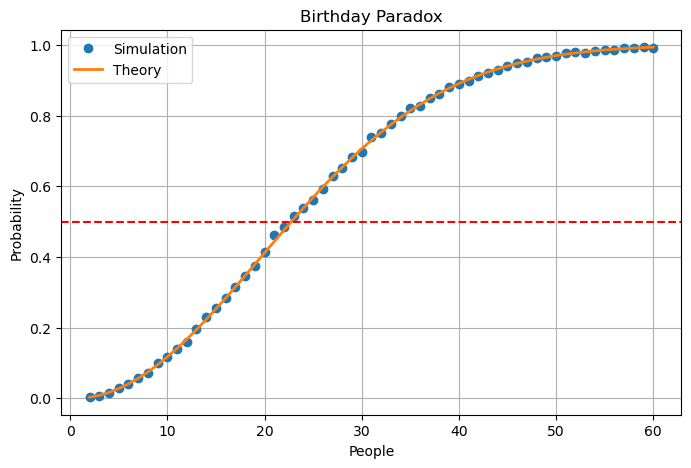

In [16]:
import random
import numpy as np
import matplotlib.pyplot as plt

num_trials = 5000
people = np.arange(2,61)

sim = []
theory = []

for n in people:

    count = 0

    for _ in range(num_trials):

        birthdays = [random.randint(1,365) for _ in range(n)]

        if len(set(birthdays)) < n:
            count += 1

    sim.append(count/num_trials)

    p = 1

    for i in range(n):
        p *= (365-i)/365

    theory.append(1-p)

plt.figure(figsize=(8,5))

plt.plot(people,sim,'o',label="Simulation")

plt.plot(people,theory,label="Theory",linewidth=2)

plt.axhline(0.5,color='red',linestyle='--')

plt.xlabel("People")

plt.ylabel("Probability")

plt.title("Birthday Paradox")

plt.legend()

plt.grid(True)

plt.show()

# Monty hall problem 

In [17]:
import random

num_trials = 100000

stay_wins = 0
switch_wins = 0

for _ in range(num_trials):

    # Randomly place the car
    car = random.randint(0, 2)

    # Player's first choice
    choice = random.randint(0, 2)

    # Host opens a goat door
    possible = []

    for door in range(3):
        if door != choice and door != car:
            possible.append(door)

    host = random.choice(possible)

    # Remaining unopened door
    for door in range(3):
        if door != choice and door != host:
            switch = door

    # Strategy 1: Stay
    if choice == car:
        stay_wins += 1

    # Strategy 2: Switch
    if switch == car:
        switch_wins += 1

print("Trials:", num_trials)

print()

print("Stay Strategy")
print("----------------")
print("Win probability =", stay_wins / num_trials)

print()

print("Switch Strategy")
print("----------------")
print("Win probability =", switch_wins / num_trials)

Trials: 100000

Stay Strategy
----------------
Win probability = 0.33511

Switch Strategy
----------------
Win probability = 0.66489


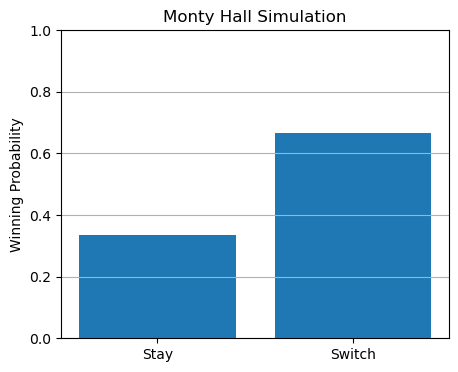

In [18]:
import matplotlib.pyplot as plt

strategies = ["Stay", "Switch"]
wins = [stay_wins / num_trials,
        switch_wins / num_trials]

plt.figure(figsize=(5,4))

plt.bar(strategies, wins)

plt.ylim(0,1)

plt.ylabel("Winning Probability")

plt.title("Monty Hall Simulation")

plt.grid(axis='y')

plt.show()

# Buffon's Needle

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------
# Buffon's Needle
# --------------------------------------

N = 100000

D = 1.0      # Distance between lines
L = 1.0      # Needle length

crossings = 0

for _ in range(N):

    # Distance from center to nearest line
    x = np.random.uniform(0, D/2)

    # Random angle
    theta = np.random.uniform(0, np.pi)

    # Crossing condition
    if x <= (L/2)*np.sin(theta):
        crossings += 1

P = crossings/N

pi_est = 2/P

print("Crossings =", crossings)
print("Estimated π =", pi_est)
print("Actual π =", np.pi)

Crossings = 63863
Estimated π = 3.1317038034542692
Actual π = 3.141592653589793


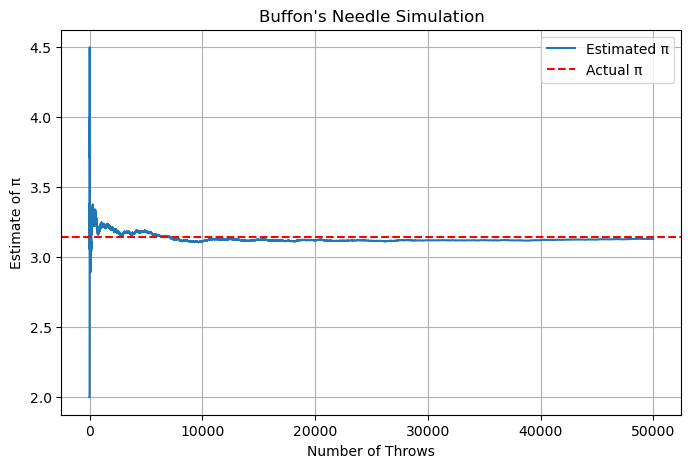

In [24]:
import numpy as np
import matplotlib.pyplot as plt

D = 1
L = 1

N = 50000

crossings = 0

pi_estimates = []

for i in range(1, N+1):

    x = np.random.uniform(0, D/2)
    theta = np.random.uniform(0, np.pi)

    if x <= (L/2)*np.sin(theta):
        crossings += 1

    if crossings > 0:
        pi_estimates.append(2*i/crossings)
    else:
        pi_estimates.append(np.nan)

plt.figure(figsize=(8,5))

plt.plot(pi_estimates, label="Estimated π")
plt.axhline(np.pi, color='red', linestyle='--', label="Actual π")

plt.xlabel("Number of Throws")
plt.ylabel("Estimate of π")
plt.title("Buffon's Needle Simulation")

plt.grid(True)
plt.legend()

plt.show()

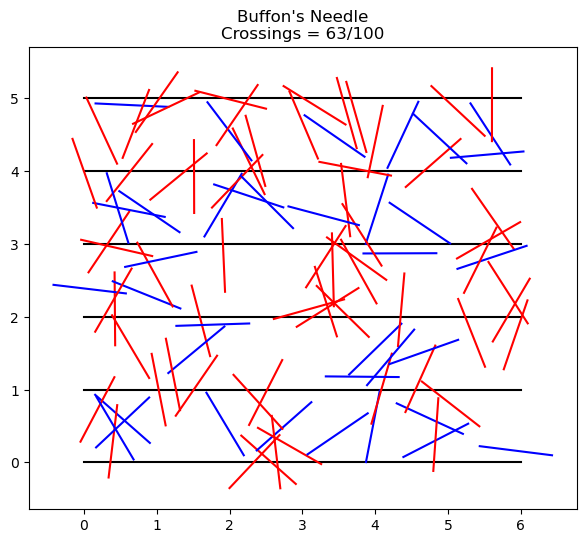

In [25]:
import numpy as np
import matplotlib.pyplot as plt

D = 1
L = 1

N = 100

plt.figure(figsize=(8,6))

# Draw floor lines
for y in np.arange(0, 6, D):
    plt.plot([0,6],[y,y],'k')

crossings = 0

for _ in range(N):

    xc = np.random.uniform(0,6)
    yc = np.random.uniform(0,5)

    theta = np.random.uniform(0,np.pi)

    dx = (L/2)*np.cos(theta)
    dy = (L/2)*np.sin(theta)

    y1 = yc-dy
    y2 = yc+dy

    # Check if endpoints lie in different strips
    if int(y1//D) != int(y2//D):
        color = 'red'
        crossings += 1
    else:
        color = 'blue'

    plt.plot([xc-dx, xc+dx],
             [y1, y2],
             color=color)

plt.gca().set_aspect('equal')
plt.title(f"Buffon's Needle\nCrossings = {crossings}/{N}")
plt.show()

# Central Limit Theorem

# Uniform → Gaussian

n=1 → Uniform
n=2 → Triangular
n=5 → Bell-shaped
n=30 → Nearly Gaussian

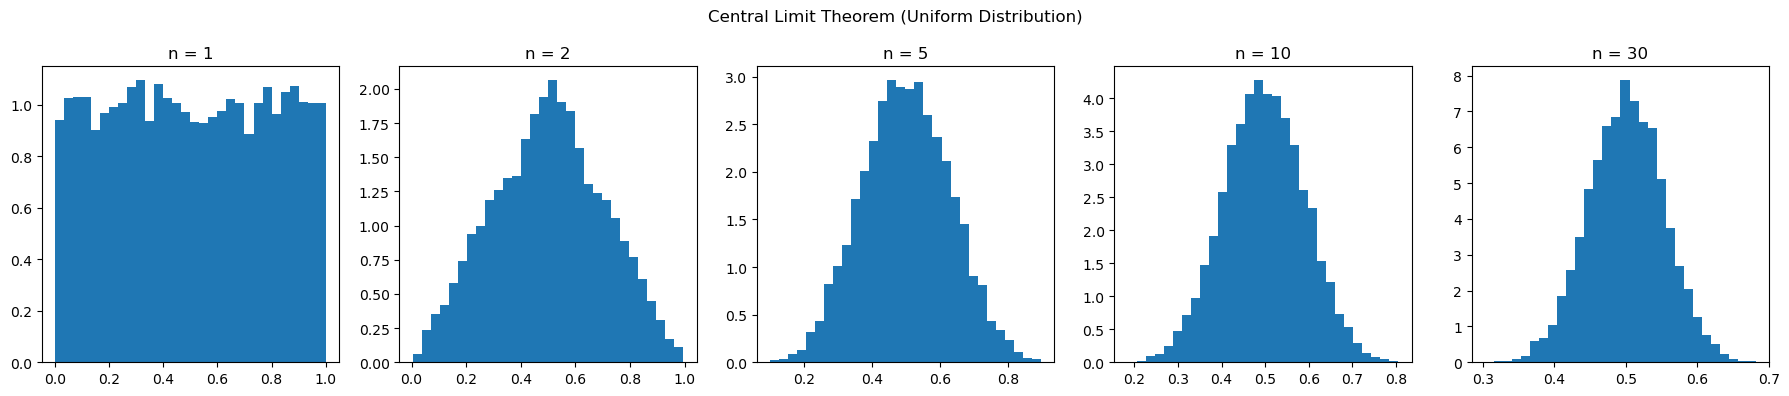

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# Central Limit Theorem
# -------------------------------------

sample_sizes = [1, 2, 5, 10, 30]
num_trials = 10000

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(18,4))

for ax, n in zip(axes, sample_sizes):

    means = []

    for _ in range(num_trials):
        sample = np.random.uniform(0, 1, n)
        means.append(np.mean(sample))

    ax.hist(means, bins=30, density=True)

    ax.set_title(f"n = {n}")

plt.suptitle("Central Limit Theorem (Uniform Distribution)")
plt.tight_layout()
plt.show()

# Dice

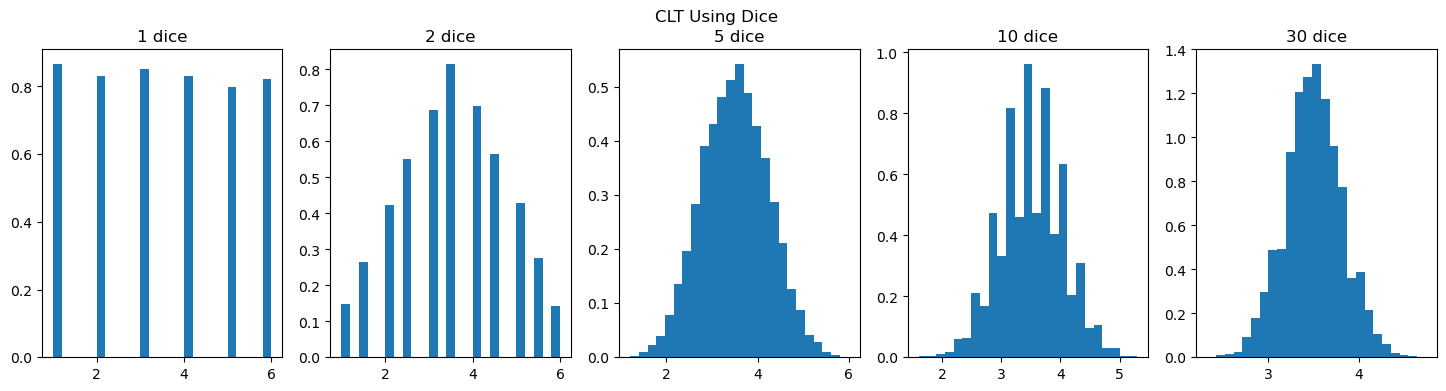

In [27]:
sample_sizes = [1,2,5,10,30]
num_trials = 10000

fig, axes = plt.subplots(1,5,figsize=(18,4))

for ax,n in zip(axes,sample_sizes):

    means=[]

    for _ in range(num_trials):

        rolls=np.random.randint(1,7,n)

        means.append(np.mean(rolls))

    ax.hist(means,bins=25,density=True)

    ax.set_title(f"{n} dice")

plt.suptitle("CLT Using Dice")

plt.show()

# Exponential Distribution

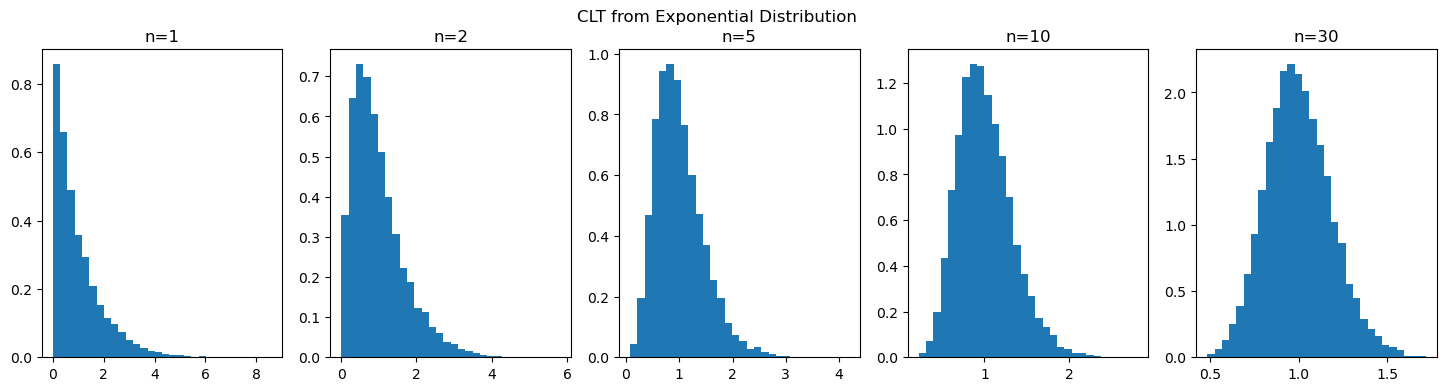

In [28]:
sample_sizes = [1,2,5,10,30]

fig,axes=plt.subplots(1,5,figsize=(18,4))

for ax,n in zip(axes,sample_sizes):

    means=[]

    for _ in range(10000):

        sample=np.random.exponential(scale=1,size=n)

        means.append(np.mean(sample))

    ax.hist(means,bins=30,density=True)

    ax.set_title(f"n={n}")

plt.suptitle("CLT from Exponential Distribution")

plt.show()

# Overlay the Gaussian

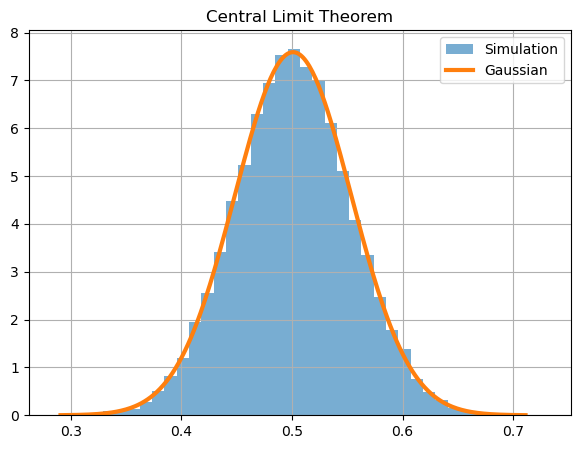

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 30
trials = 20000

means = []

for _ in range(trials):
    sample = np.random.uniform(0,1,n)
    means.append(np.mean(sample))

means = np.array(means)

mu = np.mean(means)
sigma = np.std(means)

plt.figure(figsize=(7,5))

plt.hist(means,
         bins=40,
         density=True,
         alpha=0.6,
         label="Simulation")

x = np.linspace(mu-4*sigma, mu+4*sigma,300)

plt.plot(x,
         norm.pdf(x,mu,sigma),
         linewidth=3,
         label="Gaussian")

plt.title("Central Limit Theorem")

plt.legend()

plt.grid(True)

plt.show()